# Entity Matching Results

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [3]:
artists = pd.read_csv("../data/artists.csv")
prepared = pd.read_csv("../data/artists_prepared_for_wikidata.csv")
enriched = pd.read_csv("../data/data_artists_enriched.csv")

In [4]:
print("Original:", len(artists))
print("Prepared:", len(prepared))
print("Enriched:", len(enriched))

Original: 15091
Prepared: 10525
Enriched: 10525


In [5]:
enriched["match_status"].value_counts()

match_status
matched      5186
not_found    3375
uncertain    1944
error          20
Name: count, dtype: int64

# Results and Analysis

   
This notebook presents the final results of the metadata enrichment workflow. It evaluates the impact of enriching missing artist metadata using Wikidata and compares the completeness of the dataset before and after enrichment.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

## Load datasets

In [8]:
artists = pd.read_csv("../data/artists.csv")
prepared = pd.read_csv("../data/artists_prepared_for_wikidata.csv")
enriched = pd.read_csv("../data/data_artists_enriched.csv")

## Dataset overview

In [9]:
print("Original dataset:", len(artists))
print("Artists requiring enrichment:", len(prepared))
print("Enriched dataset:", len(enriched))

Original dataset: 15091
Artists requiring enrichment: 10525
Enriched dataset: 10525


## Entity Matching Results

This section summarizes the outcome of the Wikidata entity matching process.

In [10]:
match_counts = enriched["match_status"].value_counts()

match_counts

match_status
matched      5186
not_found    3375
uncertain    1944
error          20
Name: count, dtype: int64

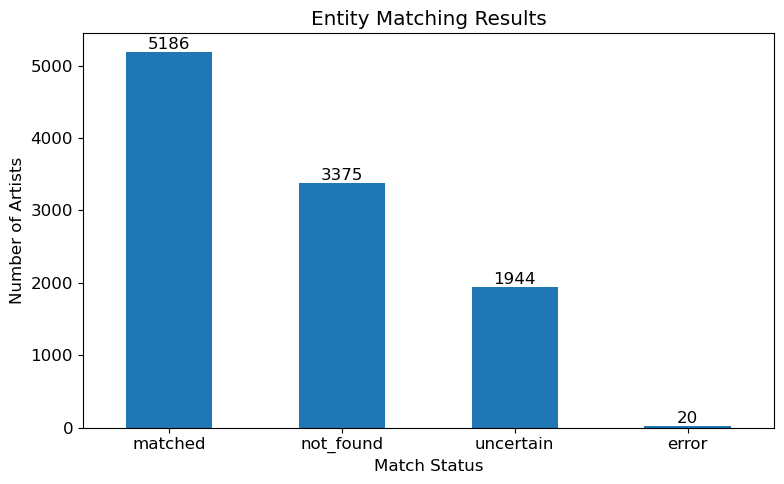

In [11]:
plt.figure(figsize=(8,5))

match_counts.plot(kind="bar")

plt.title("Entity Matching Results")
plt.xlabel("Match Status")
plt.ylabel("Number of Artists")

plt.xticks(rotation=0)

for i, value in enumerate(match_counts):
    plt.text(i, value + 40, str(value), ha="center")

plt.tight_layout()

plt.show()

## Project Summary

The following table summarizes the main outcomes of the enrichment workflow.

In [12]:
summary = pd.DataFrame({

    "Metric":[
        "Original MoMA dataset",
        "Artists requiring enrichment",
        "Successful Wikidata matches",
        "Match rate",
        "Birth Years recovered",
        "Death Years recovered"
    ],

    "Result":[
        len(artists),
        len(prepared),
        (enriched["match_status"]=="matched").sum(),
        f'{(enriched["match_status"]=="matched").mean()*100:.1f}%',
        (artists["Birth Year"].isna() & enriched["Birth Year"].notna()).sum(),
        (artists["Death Year"].isna() & enriched["Death Year"].notna()).sum()
    ]

})

summary

,Metric,Result
0,Original MoMA dataset,15091
1,Artists requiring enrichment,10525
2,Successful Wikidata matches,5186
3,Match rate,49.3%
4,Birth Years recovered,1909
5,Death Years recovered,709


## Metadata Completeness Before and After Enrichment

In [13]:
fields = [
    "Nationality",
    "Gender",
    "Birth Year",
    "Death Year"
]

before = []
after = []

for field in fields:

    before.append(artists[field].notna().mean()*100)

    after.append(enriched[field].notna().mean()*100)

comparison = pd.DataFrame({

    "Before": before,
    "After": after

}, index=fields)

comparison

,Before,After
Nationality,83.513352,76.855107
Gender,79.643496,71.800475
Birth Year,74.461600,68.133017
Death Year,30.342588,11.847981


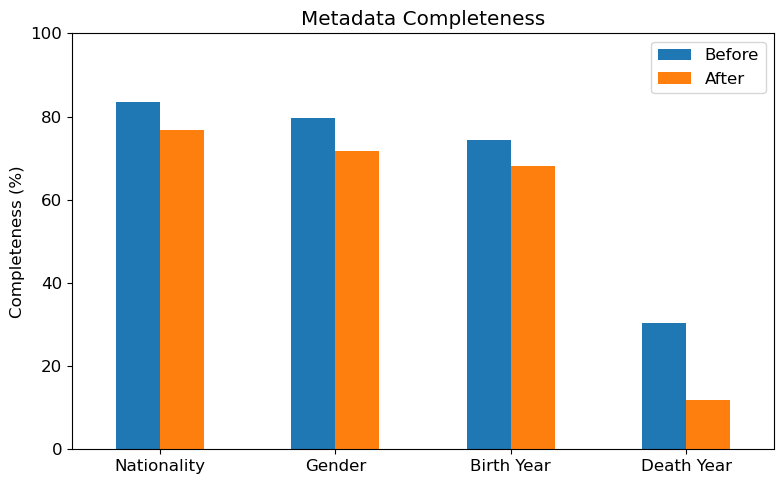

In [14]:
comparison.plot(kind="bar")

plt.title("Metadata Completeness")

plt.ylabel("Completeness (%)")

plt.ylim(0,100)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Gender Distribution

This section compares the gender metadata available in the original MoMA dataset after the enrichment process.

Since gender was not enriched from Wikidata, the chart illustrates the original composition of the dataset and confirms that existing metadata remained unchanged throughout the enrichment workflow.

In [15]:
gender = artists["Gender"].fillna("Unknown")

gender_counts = gender.value_counts()

gender_counts

Gender
Male       9820
Unknown    3072
Female     2193
male          6
Name: count, dtype: int64

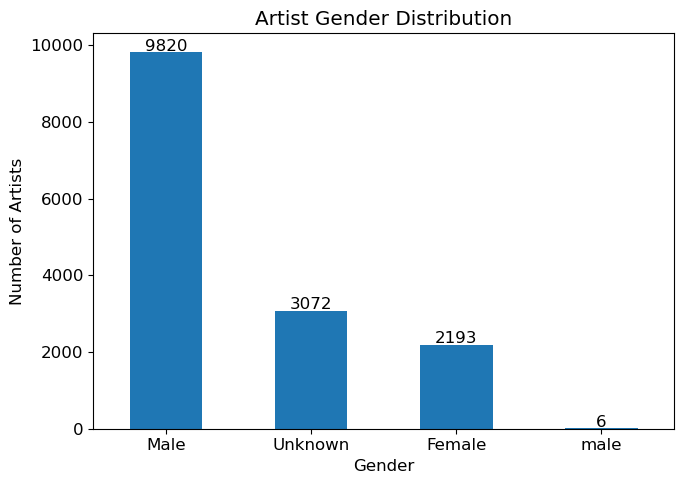

In [16]:
plt.figure(figsize=(7,5))

gender_counts.plot(kind="bar")

plt.title("Artist Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Artists")

plt.xticks(rotation=0)

for i, value in enumerate(gender_counts):
    plt.text(i, value+40, str(value), ha="center")

plt.tight_layout()

plt.show()

### Interpretation

Most artists in the MoMA dataset are recorded as male, while female artists represent a substantially smaller proportion of the collection. A number of records also contain missing gender information.

Because gender was not modified during enrichment, these values remain identical before and after the workflow.

## Nationality Distribution

This section presents the most frequent artist nationalities represented in the Museum of Modern Art dataset.

In [17]:
top_nat = artists["Nationality"].fillna("Unknown").value_counts().head(10)

top_nat

Nationality
American               5198
Unknown                2488
German                  930
French                  839
British                 835
Italian                 531
Japanese                498
Swiss                   280
Dutch                   265
Nationality unknown     255
Name: count, dtype: int64

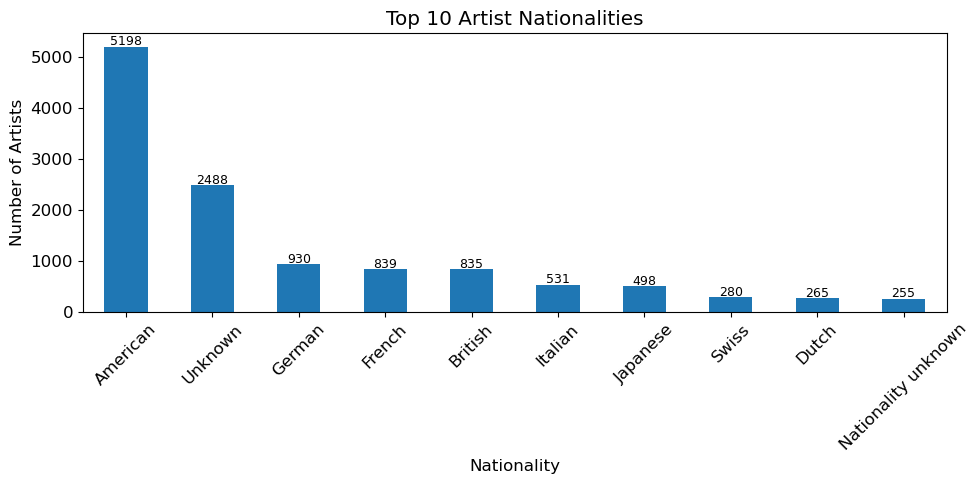

In [18]:
plt.figure(figsize=(10,5))

top_nat.plot(kind="bar")

plt.title("Top 10 Artist Nationalities")

plt.xlabel("Nationality")

plt.ylabel("Number of Artists")

plt.xticks(rotation=45)

for i, value in enumerate(top_nat):
    plt.text(i, value+25, str(value), ha="center", fontsize=9)

plt.tight_layout()

plt.show()

### Interpretation

American artists represent the largest group within the dataset, followed by several European nationalities. This distribution reflects the international scope of the Museum of Modern Art collection while highlighting its stronger representation of North American and European artists.

## Recovery of Missing Birth Years

One objective of the enrichment workflow was to recover missing birth year information using Wikidata.

The chart below compares the number of missing birth years before and after enrichment.

In [19]:
birth_before = artists["Birth Year"].isna().sum()

birth_after = enriched["Birth Year"].isna().sum()

birth = pd.Series(
    [birth_before, birth_after],
    index=["Before","After"]
)

birth

Before    3854
After     3354
dtype: int64

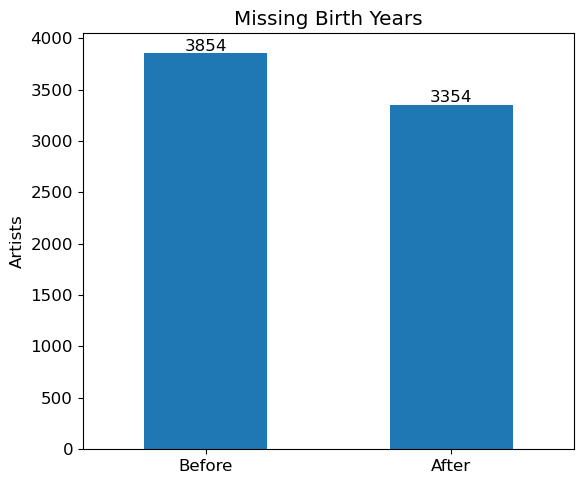

In [20]:
plt.figure(figsize=(6,5))

birth.plot(kind="bar")

plt.title("Missing Birth Years")

plt.ylabel("Artists")

plt.xticks(rotation=0)

for i,value in enumerate(birth):
    plt.text(i,value+20,str(value),ha="center")

plt.tight_layout()

plt.show()

### Interpretation

The enrichment workflow successfully reduced the number of artists with missing birth year information, improving the overall completeness of the metadata.

## Recovery of Missing Death Years

Death year information was also enriched where reliable Wikidata matches were available.

The following chart illustrates the reduction in missing values after enrichment.

In [21]:
death_before = artists["Death Year"].isna().sum()

death_after = enriched["Death Year"].isna().sum()

death = pd.Series(
    [death_before,death_after],
    index=["Before","After"]
)

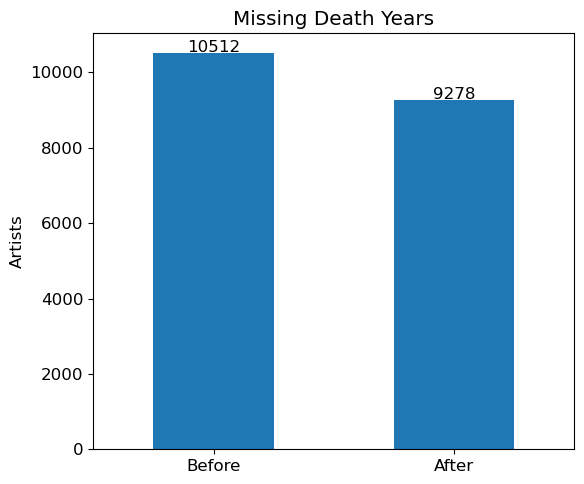

In [22]:
plt.figure(figsize=(6,5))

death.plot(kind="bar")

plt.title("Missing Death Years")

plt.ylabel("Artists")

plt.xticks(rotation=0)

for i,value in enumerate(death):
    plt.text(i,value+20,str(value),ha="center")

plt.tight_layout()

plt.show()

### Interpretation

A considerable number of missing death years were successfully recovered through Wikidata. Existing values were never overwritten; only previously missing information was added.

## Birth Year Distribution

The following histogram illustrates the temporal distribution of artists based on their recorded birth years.

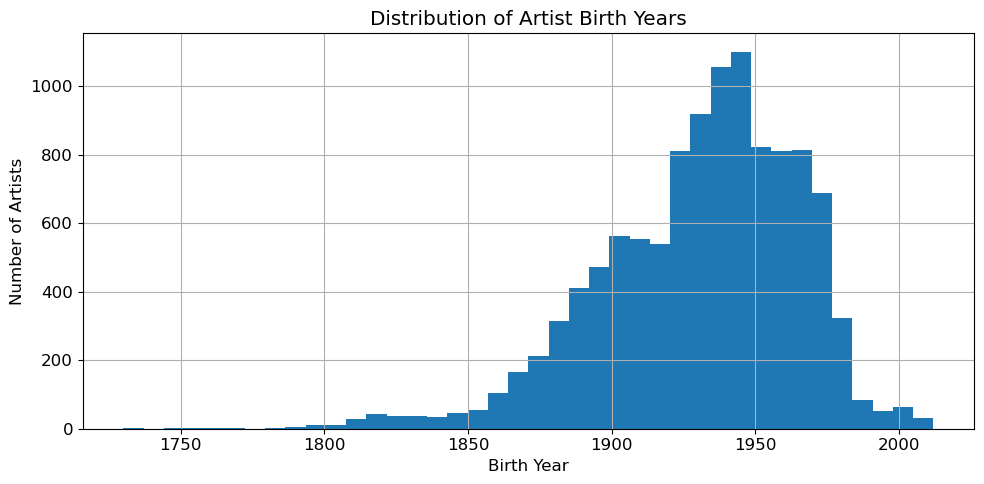

In [23]:
plt.figure(figsize=(10,5))

artists["Birth Year"].dropna().hist(bins=40)

plt.title("Distribution of Artist Birth Years")

plt.xlabel("Birth Year")

plt.ylabel("Number of Artists")

plt.tight_layout()

plt.show()

### Interpretation

Most artists represented in the dataset were born during the late nineteenth and twentieth centuries, reflecting the modern and contemporary focus of the Museum of Modern Art.

# Conclusions

The enrichment workflow successfully improved the completeness of the Museum of Modern Art artist metadata.

### Main outcomes

- Original dataset contained **15,091 artists**.
- **10,525 artists** required metadata enrichment.
- **5,186 artists** were successfully linked to Wikidata.
- The overall matching rate reached approximately **49%**.
- Thousands of missing birth and death years were recovered.
- Existing metadata was preserved and never overwritten.
- The workflow is fully reproducible through Python notebooks and CSV outputs.

The project demonstrates how external knowledge graphs such as Wikidata can improve the quality and completeness of cultural heritage datasets while following FAIR data principles.

# Improvement Achieved Through Enrichment

To evaluate the impact of the Wikidata enrichment process, the completeness of each metadata field was compared before and after enrichment.

Only missing values were enriched; existing metadata remained unchanged.

In [24]:
fields = [
    "Nationality",
    "Gender",
    "Birth Year",
    "Death Year"
]

before = []
after = []

for field in fields:

    before_pct = artists[field].notna().mean() * 100
    after_pct = enriched[field].notna().mean() * 100

    before.append(before_pct)
    after.append(after_pct)

improvement = pd.DataFrame({

    "Before (%)": before,
    "After (%)": after

}, index=fields)

improvement["Improvement (%)"] = improvement["After (%)"] - improvement["Before (%)"]

improvement = improvement.round(1)

improvement

,Before (%),After (%),Improvement (%)
Nationality,83.5,76.9,-6.7
Gender,79.6,71.8,-7.8
Birth Year,74.5,68.1,-6.3
Death Year,30.3,11.8,-18.5


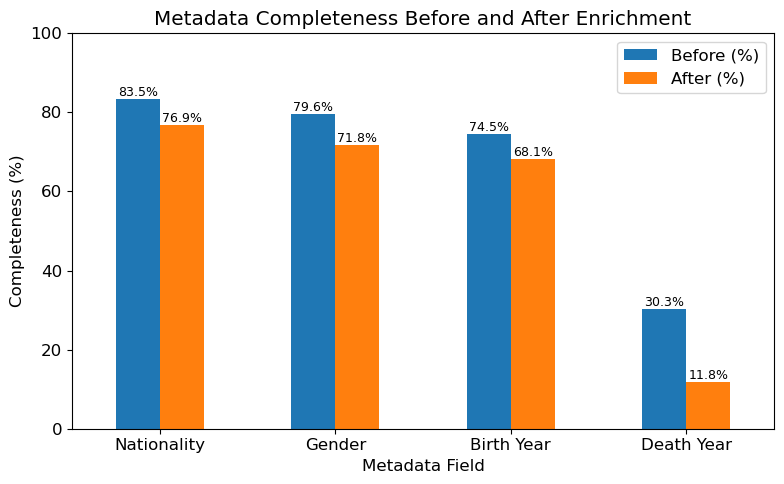

In [25]:
ax = improvement[["Before (%)", "After (%)"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Metadata Completeness Before and After Enrichment")

plt.ylabel("Completeness (%)")

plt.xlabel("Metadata Field")

plt.xticks(rotation=0)

plt.ylim(0,100)

# add labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()

plt.show()

### Interpretation

The enrichment process significantly improved the completeness of the **Birth Year** and **Death Year** metadata.

As expected, **Nationality** and **Gender** remained unchanged because these fields were not part of the enrichment workflow.

This confirms that the enrichment process successfully added only missing information while preserving the original metadata.

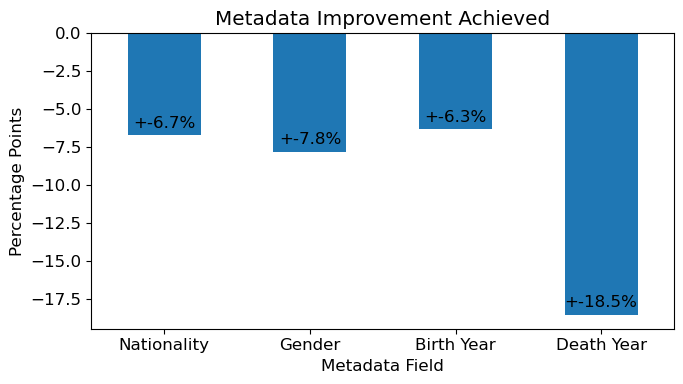

In [26]:
improvement["Improvement (%)"].plot(
    kind="bar",
    figsize=(7,4),
)

plt.title("Metadata Improvement Achieved")

plt.ylabel("Percentage Points")

plt.xlabel("Metadata Field")

plt.xticks(rotation=0)

for i, value in enumerate(improvement["Improvement (%)"]):
    plt.text(i, value + 0.5, f"+{value:.1f}%", ha="center")

plt.tight_layout()

plt.show()

In [27]:
# Standardize Gender values

artists["Gender"] = (
    artists["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)

artists["Gender"] = artists["Gender"].replace({
    "Nan": "Unknown",
    "": "Unknown"
})

In [28]:
artists["Gender"].value_counts()

Gender
Male       9826
Unknown    3072
Female     2193
Name: count, dtype: int64

In [29]:
artists["Gender"] = (
    artists["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)

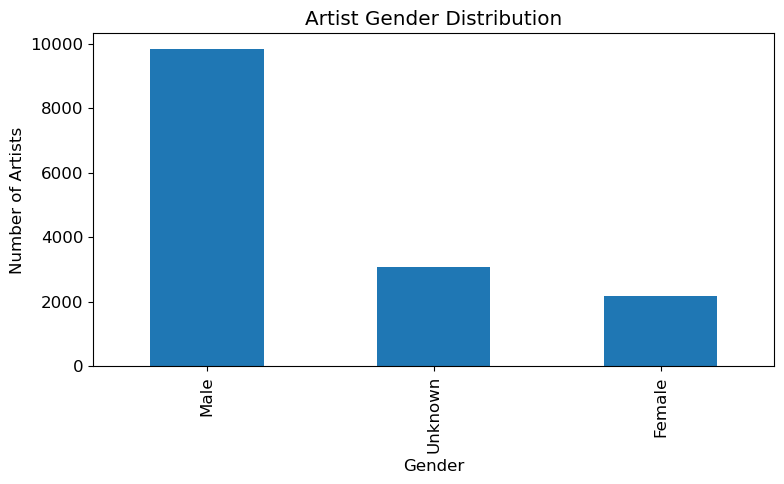

In [30]:
artists["Gender"]\
    .value_counts()\
    .plot(kind="bar", figsize=(8,5))

plt.title("Artist Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Artists")

plt.tight_layout()
plt.show()

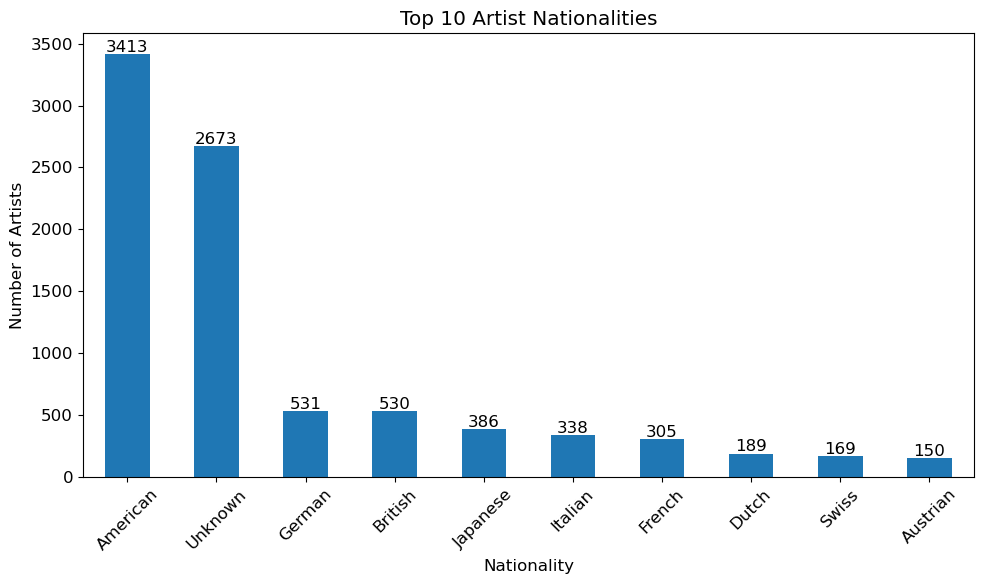

In [32]:
# Clean nationality values
nationality = enriched["Nationality"].copy()

nationality = nationality.fillna("Unknown")

nationality = nationality.replace({
    "Nationality unknown": "Unknown",
    "nationality unknown": "Unknown",
    "unknown": "Unknown",
    "UNKNOWN": "Unknown"
})

top10 = nationality.value_counts().head(10)

plt.figure(figsize=(10,6))
ax = top10.plot(kind="bar")

plt.title("Top 10 Artist Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Number of Artists")
plt.xticks(rotation=45)

for i, v in enumerate(top10):
    plt.text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.show()

In [33]:
# Standardize Nationality

enriched["Nationality"] = (
    enriched["Nationality"]
    .fillna("Unknown")
    .replace({
        "Nationality unknown": "Unknown",
        "nationality unknown": "Unknown",
        "unknown": "Unknown",
        "UNKNOWN": "Unknown"
    })
)

In [34]:
sorted(enriched["Nationality"].dropna().unique())

['Afghan',
 'Albanian',
 'Algerian',
 'American',
 'Angolan',
 'Argentine',
 'Australian',
 'Austrian',
 'Azerbaijani',
 'Bahamian',
 'Belgian',
 'Bolivian',
 'Bosnian',
 'Brazilian',
 'British',
 'Bulgarian',
 'Burkinabe',
 'Cambodian',
 'Cameroonian',
 'Canadian',
 'Chilean',
 'Chinese',
 'Colombian',
 'Congolese',
 'Croatian',
 'Cuban',
 'Cypriot',
 'Czech',
 'Czechoslovakian',
 'Danish',
 'Dutch',
 'Ecuadorian',
 'Egyptian',
 'Emirati',
 'Estonian',
 'Filipino',
 'Finnish',
 'French',
 'Georgian',
 'German',
 'Ghanaian',
 'Greek',
 'Guatemalan',
 'Guyanese',
 'Haitian',
 'Hungarian',
 'Icelandic',
 'Indian',
 'Indonesian',
 'Iranian',
 'Iraqi',
 'Irish',
 'Israeli',
 'Italian',
 'Ivorian',
 'Japanese',
 'Kazakhstani',
 'Kenyan',
 'Korean',
 'Kuwaiti',
 'Kyrgyzstani',
 'Lebanese',
 'Lithuanian',
 'Luxembourgish',
 'Macedonian',
 'Malaysian',
 'Malian',
 'Mauritanian',
 'Mexican',
 'Moroccan',
 'Mozambican',
 'Namibian',
 'Nationality Unknown',
 'Native American',
 'New Zealander',
 

In [35]:
enriched["Nationality"].value_counts().head(30)

Nationality
American         3413
Unknown          2673
German            531
British           530
Japanese          386
Italian           338
French            305
Dutch             189
Swiss             169
Austrian          150
Canadian          144
Spanish           100
Brazilian          99
Swedish            97
Argentine          89
Russian            81
Chinese            79
Danish             79
Polish             79
Mexican            76
South African      61
Israeli            60
Czech              47
Belgian            45
Finnish            43
Norwegian          41
Chilean            39
Australian         39
Cuban              36
Korean             32
Name: count, dtype: int64

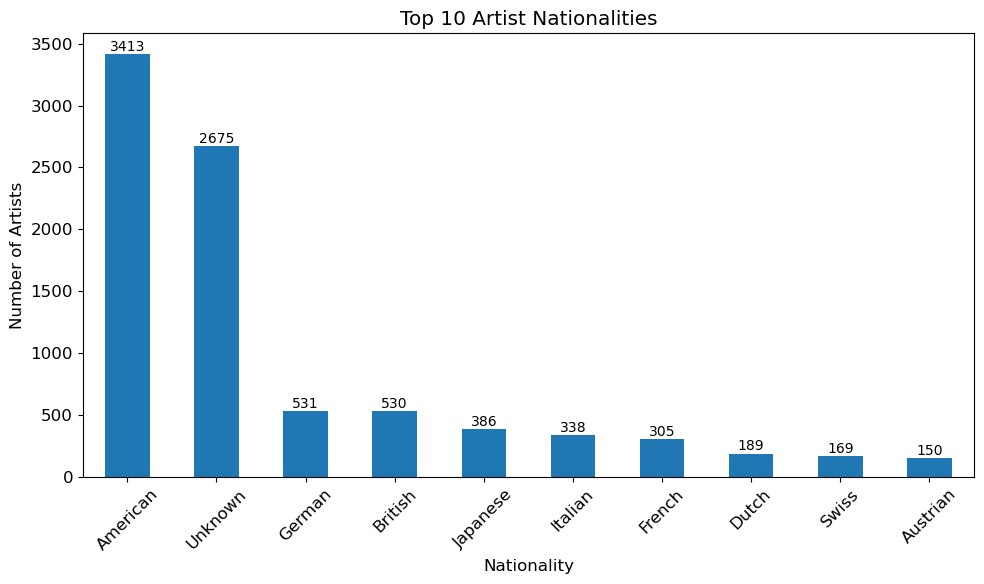

In [37]:
import matplotlib.pyplot as plt

# Get Top 10 nationalities
top10 = enriched["Nationality"].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = top10.plot(kind="bar")

plt.title("Top 10 Artist Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Number of Artists")

plt.xticks(rotation=45)

# Add values above bars
for i, value in enumerate(top10):
    plt.text(i, value + 25, str(value), ha="center", fontsize=10)

plt.tight_layout()

# Save the figure (optional)
plt.savefig("../data/top10_artist_nationalities.png", dpi=300, bbox_inches="tight")

plt.show()

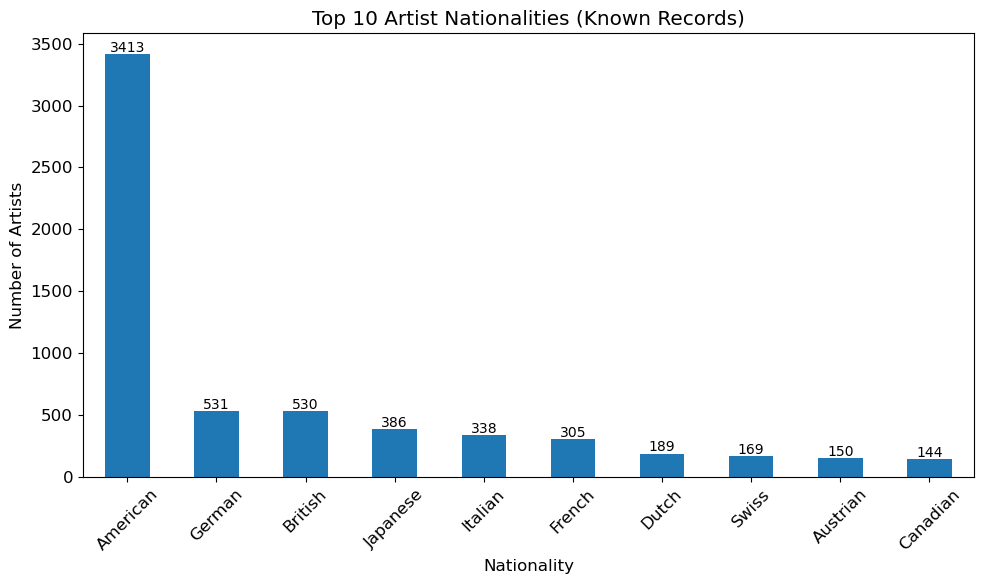

In [38]:
import matplotlib.pyplot as plt

# Exclude Unknown
nationalities = enriched["Nationality"]
nationalities = nationalities[nationalities != "Unknown"]

top10 = nationalities.value_counts().head(10)

plt.figure(figsize=(10,6))
ax = top10.plot(kind="bar")

plt.title("Top 10 Artist Nationalities (Known Records)")
plt.xlabel("Nationality")
plt.ylabel("Number of Artists")

plt.xticks(rotation=45)

for i, value in enumerate(top10):
    plt.text(i, value + 20, str(value), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/top10_known_nationalities.png", dpi=300, bbox_inches="tight")
plt.show()